In [14]:
from hullwhite import GeneratePathsHWAndAssetEuler, P0T
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

### Valoración de una call europea con tipos de interés estocásticos

Vamos a valorar una opción call europea con el modelo de tipos de interés estocástico.

Con Black–Scholes teníamos tipo de interés constante, y el precio de una call europea la veíamos como una esperanza descontada con un factor determinista.

$$
V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\left[(S_T-K)^+\right]
$$

donde:

- $V_0$ es el precio inicial de la opción;
- $T$ es el vencimiento;
- $K$ es el strike;
- $S_T$ es el precio del activo a vencimiento;
- $\mathbb{Q}$ es la medida riesgo-neutral;
- $\left(S_T-K\right)^+ = \max(S_T-K,0)$ es el payoff de la call europea.

Ahora, con el modelo actual el tipo de interés deja de ser constante. Es un proceso estocástico $r_t$ modelado mediante Hull–White. Esto implica que el descuento ya no lo puedo escribir como $e^{-rT}$. Porque el interés cambia a lo largo del tiempo.

Ahora tenemos

$$
V_0 = \mathbb{E}^{\mathbb{Q}}\left[e^{-\int_0^T r_t\,dt}\,(S_T-K)^+\right]
$$

Si comparo con Black–Scholes, veo que:

- el payoff sigue dependiendo del valor final del activo $S_T$;
- pero el factor de descuento ahora depende de $r_t$;
- la valoración incorpora dos fuentes de incertidumbre:
  - la incertidumbre del activo;
  - la incertidumbre de los tipos de interés.

La simulación Monte Carlo nos permite generar trayectorias conjuntas de $S_t$ y $r_t$ y calcular el precio como una media empírica de payoffs descontados.

---

### Interpretación financiera de la fórmula de valoración

La expresión anterior de $
V_0 $ podemos interpretarla del siguiente modo.

Para cada trayectoria:

1. Observamos el valor final del activo $S_T$;
2. Calculamos el payoff de la call, es decir, $\max(S_T-K,0)$;
3. Calculamos el descuento acumulado a lo largo de esa misma trayectoria mediante el término: $
e^{-\int_0^T r_t\,dt}$

4. Multiplicamos el payoff por dicho factor de descuento;
5. Hacemos la media de todos los valores obtenidos sobre todas las trayectorias simuladas.


### Aproximación numérica de la integral del tipo corto

En teoría, el descuento de cada trayectoria depende de la integral:

$$
\int_0^T r_t\,dt
$$

Pero en la simulación no se dispone de una trayectoria continua, sino únicamente de los valores discretos de $r_t$ en una malla temporal:

$$
0 = t_0 < t_1 < t_2 < \cdots < t_N = T
$$

con paso temporal:

$$
\Delta t = \frac{T}{N}
$$

Puedo aproximar la integral con la suma de Riemann por la izquierda:

$$
\int_0^T r_t\,dt \approx \sum_{i=0}^{N-1} r_{t_i}\,\Delta t
$$

Entonces el factor de descuento de cada trayectoria se queda como:

$$
D = \exp\left(-\sum_{i=0}^{N-1} r_{t_i}\,\Delta t\right)
$$

donde $D$ es el descuento estocástico de esa trayectoria concreta.

---

### Payoff de la call europea

El payoff de una call europea en el vencimiento solo depende del valor final del activo. Para cada trayectoria, se calcula como:

$$
\text{Payoff} = (S_T-K)^+ = \max(S_T-K,0)
$$

- si $S_T > K$, la opción se ejerce y el payoff es positivo;
- si $S_T \leq K$, la opción expira sin valor y el payoff es cero.

Aunque el payoff es igual al del caso Black–Scholes, la única diferencia es que el valor presente de ese payoff depende de una trayectoria aleatoria del tipo de interés.

---

### Estimador Monte Carlo del precio

Si simulamos $M$ trayectorias conjuntas del activo y del tipo corto, el precio puede aproximarse mediante el estimador Monte Carlo:

$$
\hat{V}_0 = \frac{1}{M}\sum_{m=1}^{M} \left[
\exp\left(-\sum_{i=0}^{N-1} r_{t_i}^{(m)}\,\Delta t\right)
\max\left(S_T^{(m)}-K,0\right)
\right]
$$

donde:

- $M$ es el número de trayectorias simuladas;
- $r_{t_i}^{(m)}$ es el valor del tipo corto en el instante $t_i$ para la trayectoria $m$;
- $S_T^{(m)}$ es el valor final del activo en la trayectoria $m$.

Este estimador es, por tanto, una media empírica de payoffs descontados trayectoria a trayectoria.

---

### Error del estimador

Si calculamos el error del estimador Monte Carlo, tendremos una medida de la precisión numérica obtenida.

Si denotamos por $X^{(m)}$ el payoff descontado de la trayectoria $m$, es decir,

$$
X^{(m)} = \exp\left(-\sum_{i=0}^{N-1} r_{t_i}^{(m)}\,\Delta t\right)
\max\left(S_T^{(m)}-K,0\right),
$$

entonces el estimador del precio es:

$$
\hat{V}_0 = \frac{1}{M}\sum_{m=1}^{M} X^{(m)}
$$

y el error estándar puede estimarse como:

$$
\text{stderr} = \frac{\text{std}(X^{(1)},\dots,X^{(M)})}{\sqrt{M}}
$$

Un error estándar pequeño en comparación con el precio estimado indica que el resultado Monte Carlo es estable.

---

### Implementación numérica

La implementación computacional del precio sigue exactamente la lógica descrita anteriormente:

1. extraer las trayectorias simuladas de $r_t$ y $S_t$;
2. calcular el paso temporal $\Delta t$;
3. aproximar la integral del tipo corto mediante una suma;
4. construir el descuento estocástico;
5. calcular el payoff de la call al vencimiento;
6. descontar el payoff trayectoria a trayectoria;
7. promediar para obtener el precio;
8. calcular el error estándar.

---

### Conclusión

El precio obtenido mediante este método refleja:

- la incertidumbre del activo financiero;
- la incertidumbre del tipo de interés;
- la posible correlación entre ambas fuentes de riesgo.

Esto supone una ampliación del marco de Black–Scholes. En el caso de tipo constante, el descuento es conocido de antemano y la incertidumbre está en el valor final del activo. En cambio, en el modelo conjunto con Hull–White, tanto el payoff como el descuento dependen de variables aleatorias simuladas.


In [2]:
def PriceEuropeanCallHWMC(paths, K, T):
    """
    Calculamos el precio de una call europea en el modelo conjunto Hull–White + activo.

    Parámetros
    ----------
    paths : dict
        Diccionario que contiene:
        - "R": trayectorias del short rate
        - "S": trayectorias del activo
    K : Strike de la call.
    T : Vencimiento.

    Devuelve
    --------
    price : Precio estimado de la call.
    stderr : Error estándar del estimador Monte Carlo.
    """

    # R tiene dimensión (número de trayectorias, número de tiempos) y contiene las simulaciones del tipo corto.
    R = paths["R"]

    # S tiene la misma estructura, pero para el precio del activo.
    S = paths["S"]


    # Si R tiene N+1 columnas, entonces hay N pasos temporales.
    NoOfSteps = R.shape[1] - 1
    dt = T / NoOfSteps

    # =========================
    # APROXIMAMOS LA INTEGRAL DEL TIPO CORTO. Con una suma de Riemann por la izquierda    #
    # Para cada trayectoria obtenemos un único valor.
    integral_r = np.sum(R[:, :-1] * dt, axis=1)

    # =========================
    # FACTOR DE DESCUENTO ESTOCÁSTICO
    # Para cada trayectoria: discount = exp( - integral_r )
    # Esto sustituye al clásico exp(-rT) de Black–Scholes.
    discount = np.exp(-integral_r)

    # PAYOFF DE LA CALL EN VENCIMIENTO
    # Tomamos el valor final del activo en cada trayectoria.
    ST = S[:, -1]

    # Payoff de la call europea: max(ST - K, 0)
    payoff = np.maximum(ST - K, 0.0)

    # PAYOFF DESCONTADO
    # Cada trayectoria genera un payoff descontado distinto, porque el descuento depende del camino seguido por r_t.
    discounted_payoff = discount * payoff

    # ESTIMADOR MONTE CARLO DEL PRECIO
    # El precio es la media de los payoffs descontados.
    price = np.mean(discounted_payoff)

    # ERROR ESTÁNDAR
    # El error estándar mide la precisión estadística del estimador.
    stderr = np.std(discounted_payoff, ddof=1) / np.sqrt(len(discounted_payoff))

    return price, stderr

In [6]:
import numpy as np
# Parámetros del modelo
NoOfPaths = 20000
NoOfSteps = 250
T = 1.0

lambd = 0.5
eta = 0.01

# Parámetros del activo
S0 = 100.0
sigma_S = 0.20
rho = -0.3

# Parámetros de la opción
K = 100.0

# Simulación conjunta de short rate y activo
paths_joint = GeneratePathsHWAndAssetEuler(
    NoOfPaths=NoOfPaths,
    NoOfSteps=NoOfSteps,
    T=T,
    P0T=P0T,
    lambd=lambd,
    eta=eta,
    S0=S0,
    sigma_S=sigma_S,
    rho=rho, None
)

# Cálculo del precio Monte Carlo
price, stderr = PriceEuropeanCallHWMC(paths_joint, K=K, T=T)

print(f"Precio de la call = {price:.6f}")
print(f"Error estándar = {stderr:.6f}")

Precio de la call = 10.413671
Error estándar = 0.104064


### Interpretación del resultado numérico

El valor obtenido representa una estimación Monte Carlo del precio de la call europea en un modelo en el que el activo y el interés (entonces también el descuento) tienen incertidumbre.

A diferencia del caso Black–Scholes, el factor de descuento no es constante, depende de la trayectoria de r. Por tanto, cada simulación genera no solo un payoff final distinto, sino también un valor presente distinto de dicho payoff.

El error estándar permite evaluar la precisión del resultado: cuanto menor sea en relación con el precio estimado, mayor será la estabilidad del estimador Monte Carlo.

In [ ]:
#si eta fuese 0 deberia salir lo mismo que en black scholes

## Validación del modelo: caso con $\eta = 0$

Vamos a comprobar que el modelo reproduce correctamente un caso límite conocido. Esto es importante porque permite verificar que la extensión con tipos estocásticos está bien construida y es consistente con el marco clásico de Black–Scholes.

Para ello, tenemos que hacer que la volatilidad del short rate es nula:$
\eta = 0
$

Recordemos que la dinámica del tipo corto bajo Hull–White es:

$$
dr_t = \lambda(\theta(t)-r_t)\,dt + \eta\,dW_t^r
$$

Si $\eta = 0$, desaparece el término aleatorio, y el tipo de interés ya no es estocástico. 

Además, suponemos una curva inicial plana:

$
P(0,T)=e^{-rT}
$

con $r=0.05$. Esto implica que el forward inicial es constante y, la media temporal del modelo coincide aproximadamente con ese mismo valor constante.

Por tanto, al anular la volatilidad del short rate, el modelo debería comportarse como el modelo de Black–Scholes con tipo constante igual al 5%. En particular, el precio de una call europea obtenido mediante simulación Monte Carlo debería aproximarse al precio analítico de Black–Scholes.

Esta comprobación permite validar simultáneamente:
- la dinámica del activo bajo medida riesgo-neutral;
- la construcción del descuento;
- la coherencia del modelo ampliado con el caso clásico conocido.

In [15]:
# Parámetros del modelo
NoOfPaths = 20000
NoOfSteps = 250
T = 1.0

lambd = 0.5
eta = 0.0   # caso de validación

# Parámetros del activo
S0 = 100.0
sigma_S = 0.20
rho = -0.3  # aquí ya no influirá realmente en r_t al no haber ruido en tipos

# Parámetros de la opción
K = 100.0

# Tipo constante de referencia de la curva plana
r = 0.05

# Simulación conjunta
paths_joint_eta0 = GeneratePathsHWAndAssetEuler(
    NoOfPaths=NoOfPaths,
    NoOfSteps=NoOfSteps,
    T=T,
    P0T=P0T,
    lambd=lambd,
    eta=eta,
    S0=S0,
    sigma_S=sigma_S,
    rho=rho, None
)

# Precio Monte Carlo en el modelo conjunto
price_mc_eta0, stderr_eta0 = PriceEuropeanCallHWMC(paths_joint_eta0, K=K, T=T)

def BS_Call_Put_Option_Price(CP,S_0,K,sigma,t,T,r):
    if T - t <= 0:
        # Opción vencida
        if CP == "call":
            return max(S_0 - K, 0)
        else:
            return max(K - S_0, 0)

    K = float(K)#np.array(K).reshape([len(K),1])
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) * (T-t)) / (sigma * np.sqrt(T-t))
    d2    = d1 - sigma * np.sqrt(T-t)
    
    if CP.lower()  == "call":
        value = norm.cdf(d1) * S_0 - norm.cdf(d2) * K * np.exp(-r * (T-t))
    elif CP.lower()  == "put":
        value = norm.cdf(-d2) * K * np.exp(-r * (T-t)) - norm.cdf(-d1)*S_0

    return value

# Precio analítico Black-Scholes
price_bs = BS_Call_Put_Option_Price("call",S0, K,sigma_S, 0, T, r)

print(f"Precio Monte Carlo (eta = 0) = {price_mc_eta0:.6f}")
print(f"Error estándar MC            = {stderr_eta0:.6f}")
print(f"Precio Black-Scholes         = {price_bs:.6f}")
print(f"Diferencia absoluta          = {abs(price_mc_eta0 - price_bs):.6f}")

Precio Monte Carlo (eta = 0) = 10.478956
Error estándar MC            = 0.104765
Precio Black-Scholes         = 10.450584
Diferencia absoluta          = 0.028373


#### Resultado de la validación con $\eta = 0$

Podemos observar que la diferencia entre el precio Monte Carlo y el precio analítico es pequeña y, además, inferior al error estándar del estimador Monte Carlo. Con esto podemos decir que la diferencia observada es compatible con la variabilidad estadística propia del método de simulación y no nos muestra ningún problema en la implementación.

En consecuencia, al imponer $\eta = 0$, el modelo con tipos de interés estocásticos recuperamos el caso clásico de Black–Scholes con tipo constante.

Esta comprobación refuerza la consistencia de la implementación.

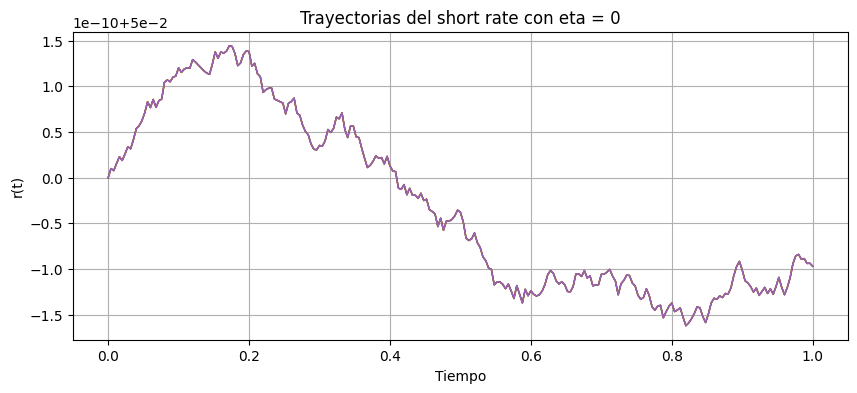

In [16]:
time = paths_joint_eta0["time"]
R_eta0 = paths_joint_eta0["R"]

plt.figure(figsize=(10, 4))
for i in range(min(5, NoOfPaths)):
    plt.plot(time, R_eta0[i, :], lw=1)

plt.title("Trayectorias del short rate con eta = 0")
plt.xlabel("Tiempo")
plt.ylabel("r(t)")
plt.grid(True)
plt.show()

##### Comportamiento del short rate con $\eta = 0$

Al imponer $\eta = 0$, desaparece la componente estocástica en la dinámica del tipo short rate. En consecuencia, el proceso se vuelve determinista y debería permanecer constante en el tiempo en el caso de una curva inicial plana.

En la simulación se observa una ligera variación en las trayectorias, del orden de $10^{-10}$. Estas desviaciones no tienen significado financiero y se deben a errores numéricos asociados a:

- la aproximación mediante diferencias finitas en la construcción de $\theta(t)$;
- la discretización temporal del esquema de Euler;

Por tanto, puede considerarse que el tipo short rate permanece constante en la práctica, confirmando que el modelo reproduce correctamente el caso límite de tipo de interés no estocástico.

#### Ejemplo: valoración de una put europea con tipos de interés estocásticos

En Black–Scholes, 
$$
V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\left[(K-S_T)^+\right]
$$

Si pasamos a tener un proceso estocástico $r_t$ modelado mediante Hull–White. Tenemos,

$$
V_0 = \mathbb{E}^{\mathbb{Q}}\left[e^{-\int_0^T r_t\,dt}\,(K-S_T)^+\right]
$$

In [18]:
def PriceEuropeanPutHWMC(paths, K, T):

    R = paths["R"]
    S = paths["S"]

    NoOfSteps = R.shape[1] - 1
    dt = T / NoOfSteps

    integral_r = np.sum(R[:, :-1] * dt, axis=1)
    discount = np.exp(-integral_r)

    ST = S[:, -1]
    payoff = np.maximum(K - ST, 0.0)

    discounted_payoff = discount * payoff

    price = np.mean(discounted_payoff)
    stderr = np.std(discounted_payoff, ddof=1) / np.sqrt(len(discounted_payoff))

    return price, stderr

In [ ]:
#funcion conjunta

In [19]:
def PriceEuropeanOptionHWMC(paths, K, T, option_type):

    R = paths["R"]
    S = paths["S"]

    NoOfSteps = R.shape[1] - 1
    dt = T / NoOfSteps

    # Aproximación de la integral del short rate
    integral_r = np.sum(R[:, :-1] * dt, axis=1)

    # Descuento estocástico
    discount = np.exp(-integral_r)

    # Precio final del activo
    ST = S[:, -1]

    # Selección del payoff según el tipo de opción
    option_type = option_type.lower()

    if option_type == "call":
        payoff = np.maximum(ST - K, 0.0)
    elif option_type == "put":
        payoff = np.maximum(K - ST, 0.0)
    else:
        raise ValueError("option_type debe ser 'call' o 'put'.")

    discounted_payoff = discount * payoff

    price = np.mean(discounted_payoff)
    stderr = np.std(discounted_payoff, ddof=1) / np.sqrt(len(discounted_payoff))

    return price, stderr